In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    SpectralClustering,
)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

sns.set_style("whitegrid")

### **Introduction**
This notebook evaluates four clustering algorithms: K-Means, Agglomerative Clustering, Gaussian Mixture Model (GMM), and Spectral Clustering, across $k=2$ to $k=8$ using three validation metrics: Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index. Each algorithm is assessed independently to identify its optimal $k$. The top three best-performing models are then selected for the final soil zone delineation.

In [3]:
df = pd.read_csv("../outputs/soil_features_scaled.csv")

CLUSTER_FEATURES = [
    "taw",
    "organic_carbon",
    "cec",
    "ph",
    "sand_pct"
]

X = df[CLUSTER_FEATURES].values
print("Feature matrix shape:", X.shape)

df[CLUSTER_FEATURES].head()

Feature matrix shape: (3422, 5)


,taw,organic_carbon,cec,ph,sand_pct
0,1.474726,-1.910414,0.164547,2.368321,1.222605
1,1.605418,-1.924883,0.163914,2.370244,1.206544
2,-0.594931,-1.328773,0.143537,2.250122,1.658395
3,-0.515371,-1.336697,0.143093,2.237952,1.621158
4,-0.434370,-1.344749,0.142641,2.227331,1.585253


In [4]:
def evaluate_clustering(X, labels):
    return {
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    }

### **1. K-Means**

In [5]:
kmeans_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X)
    metrics = evaluate_clustering(X, labels)

    kmeans_results.append({
        "model": "KMeans",
        "k": k,
        **metrics
    })

kmeans_df = pd.DataFrame(kmeans_results)
kmeans_df

,model,k,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,2,0.376670,1934.791825,1.152724
1,KMeans,3,0.470120,2602.900272,0.910910
2,KMeans,4,0.510568,2796.255773,0.722886
3,KMeans,5,0.462286,2765.716964,0.765857
4,KMeans,6,0.426114,2863.959907,0.852995
5,KMeans,7,0.417930,2912.442801,0.863338
6,KMeans,8,0.415298,2806.055323,0.853211


#### **Elbow Plot**

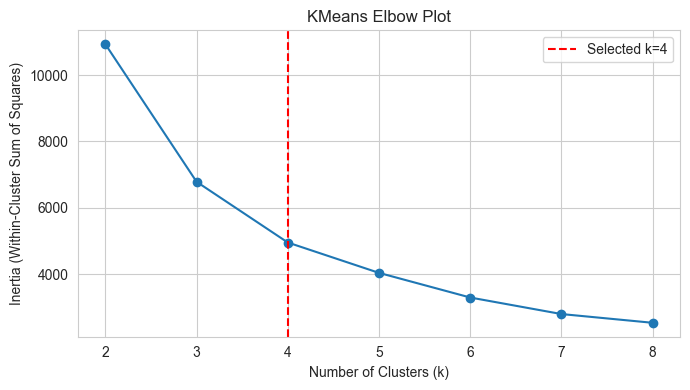

In [6]:
inertias = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 9), inertias, marker="o")
plt.axvline(4, color="red", linestyle="--", label="Selected k=4")
plt.title("KMeans Elbow Plot")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.legend()
plt.tight_layout()
plt.show()

**Elbow Plot Interpretation:**\
The inertia curve declines continuously across the tested range with no sharp inflection point. The rate of decrease gradually slows after $k=4$, but there is no clean elbow. The elbow plot is therefore inconclusive on its own, and the three validation metrics below are used to guide the final selection.

#### **Validation Metrics**

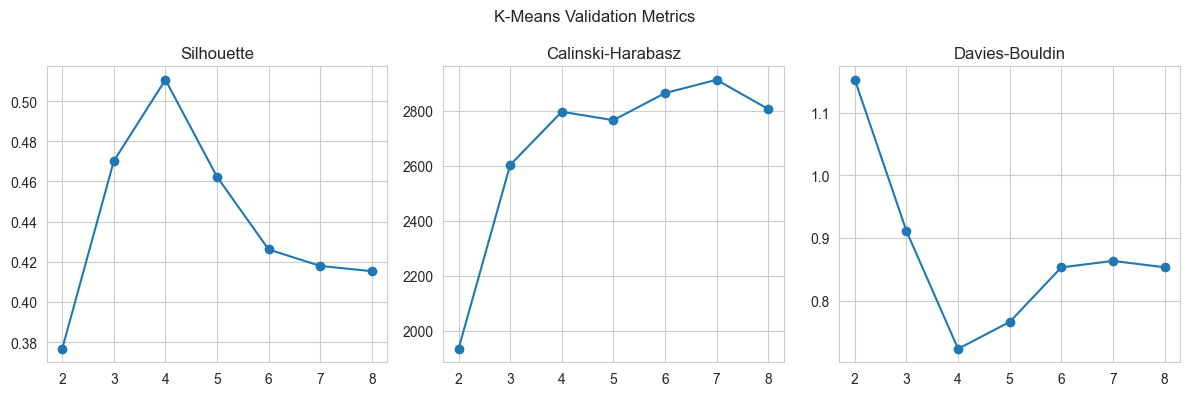

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(kmeans_df.k, kmeans_df.silhouette, marker="o")
plt.title("Silhouette")

plt.subplot(1, 3, 2)
plt.plot(kmeans_df.k, kmeans_df.calinski_harabasz, marker="o")
plt.title("Calinski-Harabasz")

plt.subplot(1, 3, 3)
plt.plot(kmeans_df.k, kmeans_df.davies_bouldin, marker="o")
plt.title("Davies-Bouldin")

plt.suptitle("K-Means Validation Metrics")
plt.tight_layout()
plt.show()

All three metrics converge on $k=4$ as the optimal choice for K-Means.

**Silhouette Score:**\
Rises steadily from 0.377 at $k=2$ to a clear peak of 0.511 at $k=4$, then declines for all larger $k$, reaching 0.415 at $k=8$. The peak at $k=4$ indicates the strongest cluster cohesion and separation.

**Calinski-Harabasz Index:**\
Climbs from 1934 at $k=2$ to 2796 at $k=4$, dips slightly at $k=5$ (2765), then rises to a secondary peak at $k=7$ (2912) before falling at $k=8$ (2806). The secondary peak at $k=7$ coincides with deteriorating Silhouette and Davies-Bouldin scores, making $k=4$ the more reliable choice overall.

**Davies-Bouldin Index:**\
Decreases from 1.153 at $k=2$ to a clear minimum of 0.723 at $k=4$, then increases and remains elevated for all $k \geq 5$. The minimum at $k=4$ confirms the most compact and well-separated clustering in the tested range.

**Conclusion:** $k=4$ is the optimal choice for K-Means, simultaneously achieving the highest Silhouette, the lowest Davies-Bouldin, and a strong Calinski-Harabasz score.

### **2. Agglomerative Clustering**

In [8]:
agg_results = []

for k in range(2, 9):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    labels = model.fit_predict(X)
    metrics = evaluate_clustering(X, labels)

    agg_results.append({
        "model": "Agglomerative",
        "k": k,
        **metrics
    })

agg_df = pd.DataFrame(agg_results)
agg_df

,model,k,silhouette,calinski_harabasz,davies_bouldin
0,Agglomerative,2,0.360051,1746.607935,1.187620
1,Agglomerative,3,0.458790,2284.986712,0.962333
2,Agglomerative,4,0.493128,2476.063149,0.723230
3,Agglomerative,5,0.460000,2572.883896,0.838881
4,Agglomerative,6,0.419655,2772.408228,0.872598
5,Agglomerative,7,0.396894,2694.471402,0.892560
6,Agglomerative,8,0.402072,2661.817943,0.859866


Agglomerative Clustering with Ward linkage identifies $k=4$ as the optimal number of clusters, consistent with the K-Means result.

**Silhouette Score:**\
Rises from 0.360 at $k=2$ to a peak of 0.493 at $k=4$, then declines for all $k \geq 5$, reaching 0.402 at $k=8$.

**Calinski-Harabasz Index:**\
Reaches 2476 at $k=4$ and continues rising to a higher value at $k=6$ (2772). However, this increase at $k=5$-$6$ is accompanied by simultaneous deterioration in Silhouette and Davies-Bouldin, indicating the higher CH values at those points do not reflect genuinely better clusters.

**Davies-Bouldin Index:**\
Drops from 1.188 at $k=2$ to a minimum of 0.723 at $k=4$, then rises and stabilises around 0.86-0.89 for $k=5$-$8$.

**Conclusion:** Silhouette and Davies-Bouldin both identify $k=4$ as optimal. The Calinski-Harabasz index peaks later but its secondary peaks are not corroborated by the other metrics. $k=4$ represents the most consistent and well supported choice for Agglomerative Clustering.

#### **Dendrogram**

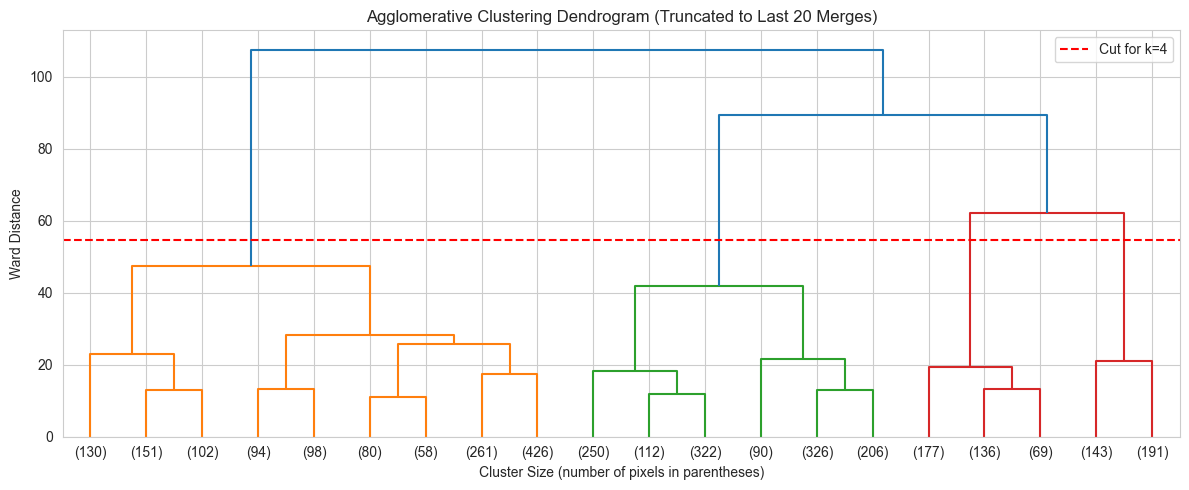

Distance at k=4 cut: 47.478
Distance at k=3 cut: 62.138
Distance at k=2 cut: 89.480


In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_font_size=10)
plt.title("Agglomerative Clustering Dendrogram (Truncated to Last 20 Merges)")
plt.xlabel("Cluster Size (number of pixels in parentheses)")
plt.ylabel("Ward Distance")
plt.axhline(
    y=(Z[-4, 2] + Z[-3, 2]) / 2,
    color="red",
    linestyle="--",
    label="Cut for k=4"
)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Distance at k=4 cut: {Z[-4, 2]:.3f}")
print(f"Distance at k=3 cut: {Z[-3, 2]:.3f}")
print(f"Distance at k=2 cut: {Z[-2, 2]:.3f}")

**Dendrogram Interpretation:**

| Merge | Distance | Gap |
|-------|----------|-----|
| $k=4 \to k=3$ | 62.138 | +14.66 |
| $k=3 \to k=2$ | 89.480 | +27.34 |

The largest distance jump occurs at the $k=3 \to k=2$ merge, meaning the dendrogram alone would suggest $k=3$ as the most natural hierarchical cut. The gap between $k=4$ and $k=3$ is meaningful but smaller. The dendrogram is treated as supplementary evidence here, the three quantitative validation metrics, which all identify $k=4$ as optimal, carry more weight in the final selection.

### **3. Gaussian Mixture Model (GMM)**

In [10]:
gmm_results = []

for k in range(2, 9):
    model = GaussianMixture(
        n_components=k,
        random_state=42
    )
    labels = model.fit_predict(X)
    metrics = evaluate_clustering(X, labels)

    gmm_results.append({
        "model": "GMM",
        "k": k,
        **metrics
    })

gmm_df = pd.DataFrame(gmm_results)
gmm_df

,model,k,silhouette,calinski_harabasz,davies_bouldin
0,GMM,2,0.367668,1682.782980,1.260972
1,GMM,3,0.469926,2500.878566,0.963612
2,GMM,4,0.501307,2650.094631,0.732837
3,GMM,5,0.396917,2331.398983,1.064849
4,GMM,6,0.444995,2314.374051,0.824374
5,GMM,7,0.399643,2060.038185,0.903749
6,GMM,8,0.351801,2334.867946,0.945373


All three metrics converge on $k=4$ as the optimal choice for GMM.

**Silhouette Score:**\
Rises from 0.368 at $k=2$ to a peak of 0.501 at $k=4$, then drops notably at $k=5$ (0.397) and fluctuates without recovering for $k \geq 5$. The peak at $k=4$ is clear and unambiguous.

**Calinski-Harabasz Index:**\
Climbs steadily from 1682 at $k=2$ to a peak of 2650 at $k=4$, then declines overall for all larger $k$, reaching its lowest value at $k=7$ (2060). Unlike K-Means, GMM's CH index shows no secondary peak, making $k=4$ the clearest choice.

**Davies-Bouldin Index:**\
Decreases from 1.261 at $k=2$ to a minimum of 0.733 at $k=4$, then worsens significantly at $k=5$ (1.065) and remains elevated thereafter. The minimum at $k=4$ confirms the tightest cluster separation.

**Conclusion:** All three metrics simultaneously reach their optimum at $k=4$ for GMM. The convergence is clear and consistent, with no competing signal from other $k$ values.

#### **AIC / BIC**

 k       AIC       BIC
 2 26159.212 26410.869
 3 16097.782 16478.336
 4 15016.284 15525.736
 5 11425.398 12063.748
 6 12289.449 13056.697
 7 10332.184 11228.329
 8  6742.158  7767.201


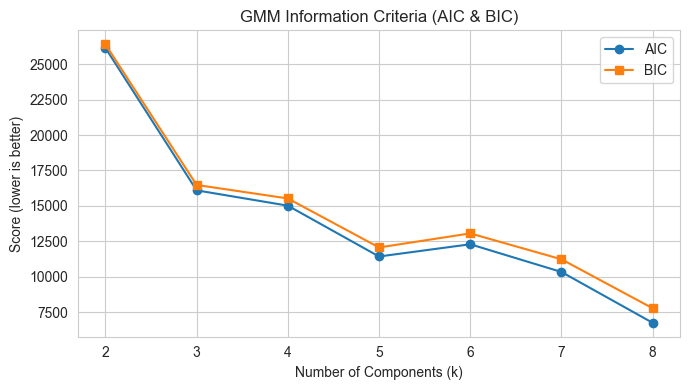

In [11]:
gmm_ic_results = []

for k in range(2, 9):
    model = GaussianMixture(n_components=k, random_state=42)
    model.fit(X)
    gmm_ic_results.append({
        "k": k,
        "AIC": round(model.aic(X), 3),
        "BIC": round(model.bic(X), 3)
    })

ic_df = pd.DataFrame(gmm_ic_results)
print(ic_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.plot(ic_df.k, ic_df.AIC, marker="o", label="AIC")
plt.plot(ic_df.k, ic_df.BIC, marker="s", label="BIC")
plt.title("GMM Information Criteria (AIC & BIC)")
plt.xlabel("Number of Components (k)")
plt.ylabel("Score (lower is better)")
plt.legend()
plt.tight_layout()
plt.show()

Both AIC and BIC decrease monotonically across the full tested range with no minimum:

| k | AIC | BIC |
|---|-----|-----|
| 2 | 26159.211 | 26410.869 |
| 3 | 16097.782 | 16478.336 |
| 4 | 12547.216 | 13056.668 |
| 5 | 10435.088 | 11073.438 |
| 6 | 7874.677 | 8641.925 |
| 7 | 5726.028 | 6622.173 |
| 8 | 4183.645 | 5208.688 |

This is a known consequence of spatial autocorrelation in geospatial datasets. Neighbouring pixels share soil parent material, meaning the effective independent sample size is considerably smaller than the raw pixel count of 3,422. Because AIC and BIC penalise model complexity relative to raw sample size, they underestimate the true penalty and continue rewarding additional components indefinitely. AIC and BIC are therefore uninformative for $k$ selection in this dataset, and the geometric validation metrics are relied upon instead.

### **4. Spectral Clustering**

In [12]:
spec_results = []

for k in range(2, 7):
    model = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=22,
        random_state=42
    )
    labels = model.fit_predict(X)
    metrics = evaluate_clustering(X, labels)

    spec_results.append({
        "model": "Spectral",
        "k": k,
        **metrics
    })

spec_df = pd.DataFrame(spec_results)
spec_df

,model,k,silhouette,calinski_harabasz,davies_bouldin
0,Spectral,2,0.371897,1877.812396,1.099578
1,Spectral,3,0.459108,2464.719524,0.972014
2,Spectral,4,0.303577,1704.302071,0.941627
3,Spectral,5,0.228542,1298.900752,0.993179
4,Spectral,6,0.121332,1159.352147,1.183717


Spectral Clustering identifies $k=3$ as optimal and shows significant sensitivity to graph construction parameters throughout.

**Graph Connectivity Note:**\
$\text{n\_neighbors=22}$ was required to eliminate "Graph is not fully connected" warnings from sklearn's SpectralEmbedding. Lower values produced disconnected graph components, leading to unreliable Laplacian decompositions. While 22 neighbours resolves connectivity, it creates a dense affinity graph that may smooth genuine cluster boundaries.

**Silhouette Score:**\
Peaks at $k=3$ (0.459), then drops sharply at $k=4$ (0.304), the lowest $k=4$ result across all four algorithms tested. Continues declining to 0.121 at $k=6$.

**Calinski-Harabasz Index:**\
Highest at $k=3$ (2464), drops dramatically and continuously for $k \geq 4$ (1704 $\to$ 1298 $\to$ 1159).

**Davies-Bouldin Index:**\
Best at $k=3$ (0.972), marginally better than $k=4$ (0.942). Both values are considerably worse than the best results achieved by the other three algorithms at $k=4$.

**Conclusion:** Spectral Clustering consistently identifies $k=3$ as its optimum. Its performance at $k=4$ is the weakest of all algorithms tested across all three metrics, and its results are sensitive to the choice of $\text{n\_neighbors}$, making it the least reliable and reproducible model in this evaluation.

### **5. Final Model Selection**

#### **5.1. Summary of All Results at Optimal k**

| Model | Optimal k | Silhouette | Calinski-Harabasz | Davies-Bouldin |
|-------|-----------|------------|-------------------|----------------|
| K-Means | 4 | 0.511 | 2796 | 0.723 |
| Agglomerative | 4 | 0.493 | 2476 | 0.723 |
| GMM | 4 | 0.501 | 2650 | 0.733 |
| Spectral | 3 | 0.459 | 2464 | 0.972 |

#### **5.2. Model Assessment**

**K-Means** is the strongest performer, achieving the highest Silhouette (0.511) and lowest Davies-Bouldin (0.723) at $k=4$. All three metrics converge cleanly on $k=4$. Its hard assignment nature is also the most practically interpretable for soil zone management, every pixel belongs unambiguously to exactly one zone. **Selected.**

**GMM** is the second strongest performer at $k=4$, with a Silhouette of 0.501 and Davies-Bouldin of 0.733, both closely trailing K-Means. Notably, all three of GMM's metrics simultaneously peak at $k=4$ with no competing signal from other $k$ values, making it the clearest convergence of any model in this evaluation. As a probabilistic model, it also offers a complementary perspective by modelling elliptical cluster shapes and soft assignment probabilities that K-Means cannot capture. **Selected.**

**Agglomerative Clustering** independently confirms $k=4$ from a hierarchical paradigm, achieving a Silhouette of 0.493 and matching K-Means on Davies-Bouldin (0.723). Its agreement with the other two selected models on the same optimal $k$, arrived at through a fundamentally different algorithm, adds cross paradigm validation to the 4 cluster conclusion. **Selected.**

**Spectral Clustering** is excluded. It identifies $k=3$ as its optimum across all three metrics, does not support the 4 cluster structure found by the other algorithms, and produces the weakest $k=4$ performance of all models tested. Its results are also sensitive to the $\text{n\_neighbors}$ graph parameter, reducing reproducibility. **Excluded.**

#### **5.3. Selected Models and k**

| Rank | Model | k |
|------|-------|---|
| 1 | K-Means | 4 |
| 2 | GMM | 4 |
| 3 | Agglomerative Clustering | 4 |

All three selected models independently converge on $k=4$, from a centroid based, a probabilistic, and a hierarchical paradigm respectively, providing strong, cross paradigm evidence that 4 soil zones is the most meaningful and stable segmentation of the Western Province soil data.

### **6. Soil Cluster Generation**

In [14]:
# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster_kmeans"] = kmeans.fit_predict(X)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
df["cluster_agg"] = agg.fit_predict(X)

# GMM
gmm = GaussianMixture(n_components=4, random_state=42)
df["cluster_gmm"] = gmm.fit_predict(X)

df_original = pd.read_csv("../outputs/soil_features_final.csv")

labels_df = df[["taw", "organic_carbon", "cec", "ph", "sand_pct",
                 "cluster_kmeans", "cluster_agg", "cluster_gmm"]].copy()
labels_df["lon"] = df_original["lon"].values
labels_df["lat"] = df_original["lat"].values

df_original = df_original.merge(
    labels_df[["lon", "lat", "cluster_kmeans", "cluster_agg", "cluster_gmm"]],
    on=["lon", "lat"],
    how="left"
)

df_original.to_csv("../outputs/soil_clusters_top_3_models.csv", index=False)

print("Soil clusters saved.")
print(f"KMeans        — {df['cluster_kmeans'].value_counts().sort_index().to_dict()}")
print(f"Agglomerative — {df['cluster_agg'].value_counts().sort_index().to_dict()}")
print(f"GMM           — {df['cluster_gmm'].value_counts().sort_index().to_dict()}")

Soil clusters saved.
KMeans        — {0: 353, 1: 1305, 2: 524, 3: 1240}
Agglomerative — {0: 1400, 1: 334, 2: 1306, 3: 382}
GMM           — {0: 356, 1: 1305, 2: 513, 3: 1248}


In [15]:
df_1 = pd.read_csv("../outputs/soil_features_for_db.csv")
df_2 = pd.read_csv("../outputs/soil_clusters_top_3_models.csv")
df_3 = df_2[["lon", "lat", "cluster_kmeans", "cluster_agg", "cluster_gmm"]]

df_merged = df_1.merge(
    df_3,
    on=["lon", "lat"],
    how="left"
)

output_path = "../outputs/soil_features_for_db_final_v2.csv"
df_merged.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: ../outputs/soil_features_for_db_final_v2.csv
